# Voxelizing the dataset

For voxelizing the dataset, we first need to load the dataset in its raw `PyVista` format:

In [1]:
from cooldata.pyvista_flow_field_dataset import PyvistaFlowFieldDataset

ds_pv = PyvistaFlowFieldDataset.load_from_huggingface(
    num_samples=12, data_dir="datasets/pyvista"
)

Loaded 12 samples from '/Users/ole/Documents/software/flow_field_dataset/docs/usage/datasets/pyvista'.
Loaded 12 samples from 'datasets/pyvista'.


Next, we define a voxelization resolution, and create a voxelized dataset. The bounds are automatically determined as the minimum and maximum coordinates over the whole dataset.

In [3]:
from cooldata.voxel_flow_field_dataset import VoxelFlowFieldDataset, VoxelFlowFieldDatasetConfig

ds_voxel = VoxelFlowFieldDataset(
    cache_dir="datasets/voxels",
    config=VoxelFlowFieldDatasetConfig(
        pyvista_dataset=ds_pv, resolution=(32, 16, 16)
    ),
)

Voxelizing samples: 100%|██████████| 12/12 [00:04<00:00,  2.75it/s]


Again, we can visualize the samples in 3d:

In [5]:
import pyvista as pv
pv.set_jupyter_backend('static')

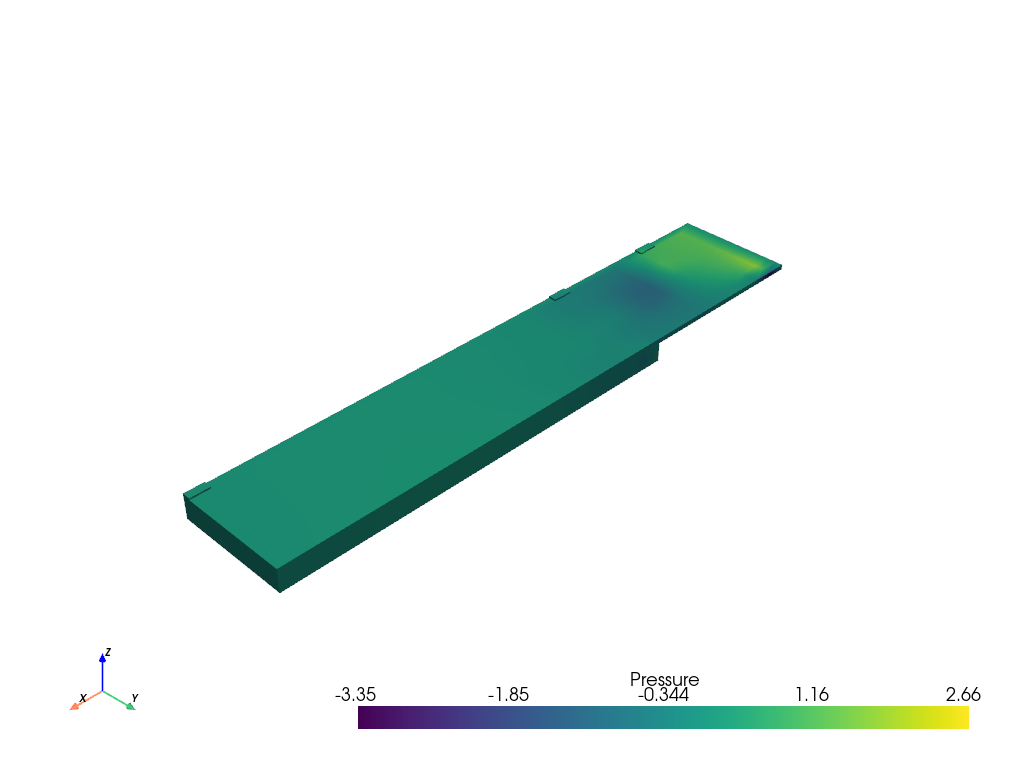

In [13]:
ds_voxel[0].plot("Pressure")

Next, we can plot a slice through the sample:

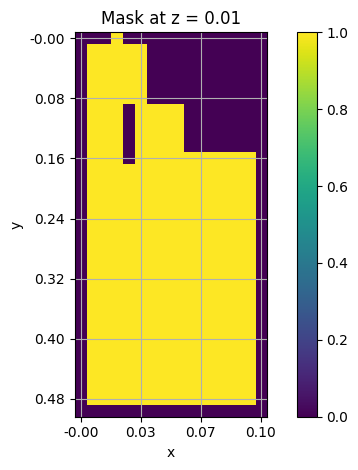

In [28]:
ds_voxel[0].plot_slice("Mask", slice_idx=9,axis="z")

Now, in order to train a model, we can convert this to a torch dataset. The samples from this dataset are tuples of the form `(mask, y)`, where `mask` is a 3d tensor of shape `(n_x, n_y, n_z)` that is `True` for all voxels that are occupied with fluid, and `y` is a tensor of shape `(n_x, n_y, n_z, 5)` that contains the flow properties at each voxel.

In [24]:
ds_torch=ds_voxel.get_default_loadable_dataset()
mask, y =ds_torch[0]
print(mask.shape, y.shape)

torch.Size([32, 16, 16]) torch.Size([32, 16, 16, 5])


However, it is often required to normalize the flow properties to have zero mean and unit variance:

In [29]:
y.mean()

tensor(37.3221)

The dataset library implements this:

In [33]:
ds_voxel.normalize()
ds_torch=ds_voxel.get_default_loadable_dataset()
mask, y = ds_torch[0]
y.mean()

tensor(-0.1331)

Now, nothing stops us from training a model on this dataset:

In [35]:
from torch.utils.data import DataLoader
dataloader = DataLoader(ds_torch, batch_size=4, shuffle=True)
for batch in dataloader:
    mask, y = batch
    print(mask.shape, y.shape)
    print(y.mean())
    # let your own model predict y from the mask
    break

torch.Size([4, 32, 16, 16]) torch.Size([4, 32, 16, 16, 5])
tensor(0.0058)


We implemented a simple 3d U-Net [here](https://github.com/peteole/flow_field_dataset/blob/main/examples/voxel_data/train.py)